In [37]:
from pyspark.sql import SparkSession    
spark = SparkSession.builder \
    .appName("nyc-taxi-trip-duration-prediction") \
    .master("local[*]") \
    .getOrCreate()

Loading the data from the final_data

In [38]:
feature_data =spark.read.parquet("../data/final_data/final_taxi_data.parquet")

In [39]:
feature_data.show(5)

+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+
|passenger_count|trip_duration|pickup_hour|pickup_month|pickup_weekday|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|vendor_id_encoded|store_and_fwd_flag_encoded|
+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+
|              2|          622|          0|           1|             6|         0|           0|       1|3.7968399392402117|-2.8737003042455274|  -0.032928466796875|-0.01192474365234375|    (1,[0],[1.0])|             (1,[0],[1.0])|
|              1|         1324|         10|           3|             3|     

In [40]:
feature_data.printSchema()

root
 |-- passenger_count: integer (nullable = true)
 |-- trip_duration: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- direction: double (nullable = true)
 |-- latitude_difference: double (nullable = true)
 |-- longitude_difference: double (nullable = true)
 |-- vendor_id_encoded: vector (nullable = true)
 |-- store_and_fwd_flag_encoded: vector (nullable = true)



In [41]:
# by using vector assembler we will convert all the features into a single vector column which is required for machine learning models in spark
from pyspark.ml.feature import VectorAssembler
feature_columns=[col for col in feature_data.columns if col!="trip_duration"]
assembler=VectorAssembler(inputCols=feature_columns, outputCol="features")

feature_data=assembler.transform(feature_data)
feature_data.show(5)


+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+--------------------+
|passenger_count|trip_duration|pickup_hour|pickup_month|pickup_weekday|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|vendor_id_encoded|store_and_fwd_flag_encoded|            features|
+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+--------------------+
|              2|          622|          0|           1|             6|         0|           0|       1|3.7968399392402117|-2.8737003042455274|  -0.032928466796875|-0.01192474365234375|    (1,[0],[1.0])|             (1,[0],[1.0])|[2.0,0.0,1.0,6

In [42]:
final_data=feature_data.select("features","trip_duration")
final_data.show(5)

+--------------------+-------------+
|            features|trip_duration|
+--------------------+-------------+
|[2.0,0.0,1.0,6.0,...|          622|
|[1.0,10.0,3.0,3.0...|         1324|
|[1.0,23.0,6.0,7.0...|          455|
|[6.0,19.0,3.0,2.0...|          206|
|[1.0,18.0,1.0,5.0...|         2585|
+--------------------+-------------+
only showing top 5 rows


separating input_data and label_data


In [43]:
# splitting the data into training and testing sets
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

In [44]:
from pyspark.ml.regression import LinearRegression
linear_regressor=LinearRegression(featuresCol='features', labelCol='trip_duration')
linear_model=linear_regressor.fit(train_data)

26/03/20 09:05:44 WARN Instrumentation: [1a087d19] regParam is zero, which might cause numerical instability and overfitting.


In [45]:
linear_regressor_prediction=linear_model.transform(test_data)
linear_regressor_prediction.show(5)

+--------------------+-------------+------------------+
|            features|trip_duration|        prediction|
+--------------------+-------------+------------------+
|(13,[0,1,2,3],[1....|          267| 559.7512451778996|
|(13,[0,1,2,3,4,5,...|           73|367.43319519488693|
|(13,[0,1,2,3,4,5,...|          129| 330.5814876536516|
|(13,[0,1,2,3,4,5,...|          585| 416.6787050692809|
|(13,[0,1,2,3,4,6,...|          181| 200.6074025170937|
+--------------------+-------------+------------------+
only showing top 5 rows


Evaluate in Spark ML

In [46]:
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="rmse")
mae_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="mae")
r2_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="r2")
rmse=rmse_evaluator.evaluate(linear_regressor_prediction)
mae=mae_evaluator.evaluate(linear_regressor_prediction)
r2=r2_evaluator.evaluate(linear_regressor_prediction)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Root Mean Squared Error (RMSE): 403.4549097457446
Mean Absolute Error (MAE): 276.88176357508377
R-squared (R2): 0.6179114237920766


In [47]:
# decision tree regressor
from pyspark.ml.regression import DecisionTreeRegressor
decision_tree_regressor=DecisionTreeRegressor(featuresCol='features', labelCol='trip_duration')
decision_tree_model=decision_tree_regressor.fit(train_data)


26/03/20 09:05:52 WARN MemoryStore: Not enough space to cache rdd_1853_0 in memory! (computed 12.8 MiB so far)
26/03/20 09:05:52 WARN BlockManager: Persisting block rdd_1853_0 to disk instead.
26/03/20 09:05:52 WARN MemoryStore: Not enough space to cache rdd_1853_5 in memory! (computed 12.8 MiB so far)
26/03/20 09:05:52 WARN BlockManager: Persisting block rdd_1853_5 to disk instead.
26/03/20 09:05:52 WARN MemoryStore: Not enough space to cache rdd_1853_7 in memory! (computed 19.7 MiB so far)
26/03/20 09:05:52 WARN BlockManager: Persisting block rdd_1853_7 to disk instead.
26/03/20 09:05:52 WARN MemoryStore: Not enough space to cache rdd_1853_4 in memory! (computed 19.7 MiB so far)
26/03/20 09:05:52 WARN BlockManager: Persisting block rdd_1853_4 to disk instead.
26/03/20 09:05:52 WARN MemoryStore: Not enough space to cache rdd_1853_1 in memory! (computed 12.8 MiB so far)
26/03/20 09:05:52 WARN BlockManager: Persisting block rdd_1853_1 to disk instead.


In [48]:
decision_tree_prediction=decision_tree_model.transform(test_data)
decision_tree_prediction.show(5)

+--------------------+-------------+-----------------+
|            features|trip_duration|       prediction|
+--------------------+-------------+-----------------+
|(13,[0,1,2,3],[1....|          267|337.1219112465856|
|(13,[0,1,2,3,4,5,...|           73|337.1219112465856|
|(13,[0,1,2,3,4,5,...|          129|337.1219112465856|
|(13,[0,1,2,3,4,5,...|          585|337.1219112465856|
|(13,[0,1,2,3,4,6,...|          181|266.5768796175576|
+--------------------+-------------+-----------------+
only showing top 5 rows


In [49]:
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="rmse")
mae_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="mae")
r2_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="r2")
rmse=rmse_evaluator.evaluate(decision_tree_prediction)
mae=mae_evaluator.evaluate(decision_tree_prediction)
r2=r2_evaluator.evaluate(decision_tree_prediction)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Root Mean Squared Error (RMSE): 378.0740050427893
Mean Absolute Error (MAE): 253.2601534397463
R-squared (R2): 0.6644728412005798


In [50]:
from pyspark.ml.regression import RandomForestRegressor
rf = RandomForestRegressor(featuresCol="features", labelCol="trip_duration")
rf_model = rf.fit(train_data)


26/03/20 09:05:59 WARN MemoryStore: Not enough space to cache rdd_1934_2 in memory! (computed 12.4 MiB so far)
26/03/20 09:05:59 WARN BlockManager: Persisting block rdd_1934_2 to disk instead.
26/03/20 09:05:59 WARN MemoryStore: Not enough space to cache rdd_1934_0 in memory! (computed 12.4 MiB so far)
26/03/20 09:05:59 WARN BlockManager: Persisting block rdd_1934_0 to disk instead.
26/03/20 09:05:59 WARN MemoryStore: Not enough space to cache rdd_1934_1 in memory! (computed 12.4 MiB so far)
26/03/20 09:05:59 WARN BlockManager: Persisting block rdd_1934_1 to disk instead.
26/03/20 09:05:59 WARN MemoryStore: Not enough space to cache rdd_1934_3 in memory! (computed 18.6 MiB so far)
26/03/20 09:05:59 WARN BlockManager: Persisting block rdd_1934_3 to disk instead.
26/03/20 09:05:59 WARN MemoryStore: Not enough space to cache rdd_1934_6 in memory! (computed 12.4 MiB so far)
26/03/20 09:05:59 WARN BlockManager: Persisting block rdd_1934_6 to disk instead.
26/03/20 09:05:59 WARN MemoryStore:

In [51]:
rf_prediction = rf_model.transform(test_data)
rf_prediction.show(5)

+--------------------+-------------+------------------+
|            features|trip_duration|        prediction|
+--------------------+-------------+------------------+
|(13,[0,1,2,3],[1....|          267|486.07179060373903|
|(13,[0,1,2,3,4,5,...|           73|505.13575331847596|
|(13,[0,1,2,3,4,5,...|          129|  484.105787372206|
|(13,[0,1,2,3,4,5,...|          585| 509.2107446247463|
|(13,[0,1,2,3,4,6,...|          181| 418.3987643882232|
+--------------------+-------------+------------------+
only showing top 5 rows


In [52]:
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="rmse")

mae_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="mae")
r2_evaluator=RegressionEvaluator(labelCol="trip_duration",predictionCol="prediction",metricName="r2")
rmse=rmse_evaluator.evaluate(rf_prediction)
mae=mae_evaluator.evaluate(rf_prediction)
r2=r2_evaluator.evaluate(rf_prediction)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Root Mean Squared Error (RMSE): 378.18944650514095
Mean Absolute Error (MAE): 259.1694878406486
R-squared (R2): 0.6642679095795083


In [53]:
from pyspark.sql.functions import col

model_df = final_data.select(
    col("features"),
    col("trip_duration").alias("label")
)

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

In [54]:
from xgboost.spark import SparkXGBRegressor
xgb = SparkXGBRegressor(features_Col="features", label_Col="label")
xgb_model = xgb.fit(train_df)

2026-03-20 09:06:05,380 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'features_Col': 'features', 'label_Col': 'label', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-20 09:06:09,293 INFO XGBoost-PySpark: _train_booster Training on CPUs 1]
[09:06:10] Task 0 got rank 0
/Users/mouninarra/Desktop/nyc-taxi-trip-duration-prediction/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:06:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "features_Col", "label_Col" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[09:06:11] [0]	training-rmse:526.49358
[09:06:11] [1]	training-rmse:448.05716
[09:06:11] [2]	training-rmse:402.20364
[09:06:11] [3]	training-rmse:374.85319
[09:06:11] [4]	training-rmse:358.89314
[09:06:11] [5]	training-rmse:348.62663


In [55]:
xgb_prediction = xgb_model.transform(test_df)
xgb_prediction.show(5)

2026-03-20 09:06:15,539 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


+--------------------+-----+------------------+
|            features|label|        prediction|
+--------------------+-----+------------------+
|(13,[0,1,2,3],[1....|  267|    621.9619140625|
|(13,[0,1,2,3,4,5,...|   73| 540.1742553710938|
|(13,[0,1,2,3,4,5,...|  129| 602.0631713867188|
|(13,[0,1,2,3,4,5,...|  585| 758.2407836914062|
|(13,[0,1,2,3,4,6,...|  181|457.18524169921875|
+--------------------+-----+------------------+
only showing top 5 rows


In [56]:
#evaluating the xgboost model
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="rmse")
mae_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="mae")
r2_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="r2")
rmse=rmse_evaluator.evaluate(xgb_prediction)
mae=mae_evaluator.evaluate(xgb_prediction)
r2=r2_evaluator.evaluate(xgb_prediction)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

2026-03-20 09:06:18,909 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-20 09:06:19,153 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-20 09:06:20,452 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Root Mean Squared Error (RMSE): 315.5671620619151
Mean Absolute Error (MAE): 206.40434169174878
R-squared (R2): 0.7662467532248172


hyperparameter tunning for xgboost

In [57]:
from pyspark.ml.tuning import ParamGridBuilder,CrossValidator
param_grid = (ParamGridBuilder()
    .addGrid(xgb.max_depth, [3, 5, 7])
    .addGrid(xgb.learning_rate, [0.05, 0.1])
    .addGrid(xgb.n_estimators, [100, 200, 300])
    .build()
)



In [58]:
evaluator=RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")


In [59]:
cross_validator = CrossValidator(estimator=xgb, estimatorParamMaps=param_grid, evaluator=evaluator, numFolds=2)

In [60]:
# run cross-validation, and choose the best set of parameters.
cv_model = cross_validator.fit(train_df)


2026-03-20 09:06:21,608 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 1 workers with
	booster params: {'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 3, 'objective': 'reg:squarederror', 'features_Col': 'features', 'label_Col': 'label', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-20 09:06:23,857 INFO XGBoost-PySpark: _train_booster Training on CPUs 1]
[09:06:24] Task 0 got rank 0
/Users/mouninarra/Desktop/nyc-taxi-trip-duration-prediction/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:06:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "features_Col", "label_Col" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[09:06:25] [0]	training-rmse:633.92205
[09:06:25] [1]	training-rmse:615.16502
[09:06:25] [2]	training-rmse:597.57280
[09:06:25] [3]	training-rmse:581.22535
[09:06:25] [4]	training-rmse:566.13798


In [61]:
best_model = cv_model.bestModel
best_model_prediction = best_model.transform(test_df)


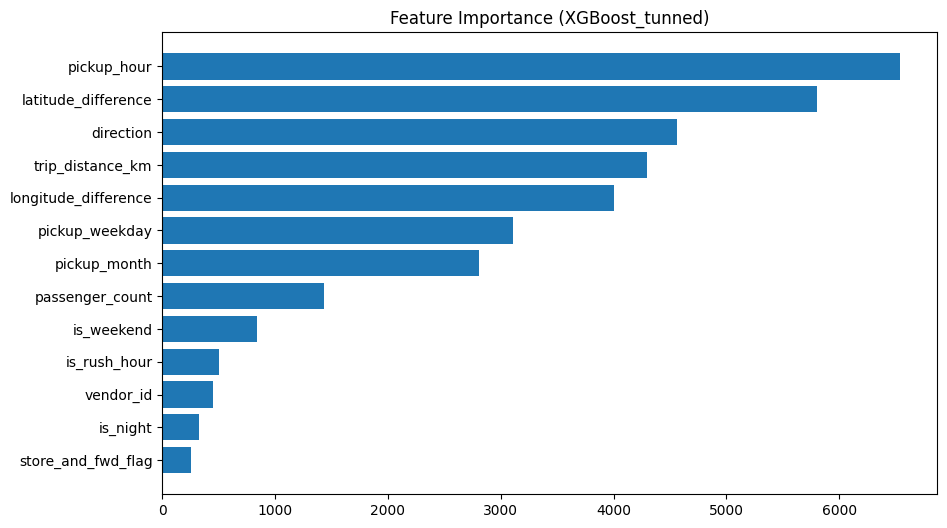

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

# get importance dictionary
importance_dict = best_model.get_booster().get_score(importance_type='weight')

# convert to dataframe
importance_df = pd.DataFrame({
    "feature": list(importance_dict.keys()),
    "importance": list(importance_dict.values())
})
feature_names = [
    "passenger_count","pickup_hour","pickup_month","pickup_weekday",
    "is_weekend","is_rush_hour","is_night",
    "trip_distance_km","latitude_difference","longitude_difference",
    "direction","vendor_id","store_and_fwd_flag"
]

importance_df["feature"] = importance_df["feature"].apply(
    lambda x: feature_names[int(x[1:])]
)

# sort
importance_df = importance_df.sort_values(by="importance", ascending=False)

# plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost_tunned)")

# save
plt.savefig("../reports/figures/feature_importance_tunned.png")
plt.show()

In [63]:
#evaluating the best model
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="rmse")
mae_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="mae")
r2_evaluator=RegressionEvaluator(labelCol="label",predictionCol="prediction",metricName="r2")
rmse=rmse_evaluator.evaluate(best_model_prediction)
mae=mae_evaluator.evaluate(best_model_prediction)
r2=r2_evaluator.evaluate(best_model_prediction)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")  

2026-03-20 09:10:58,645 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-20 09:10:59,679 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-20 09:11:00,755 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Root Mean Squared Error (RMSE): 313.7645876181677
Mean Absolute Error (MAE): 204.8656867915196
R-squared (R2): 0.7689096044039571


2026-03-20 09:11:01,780 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


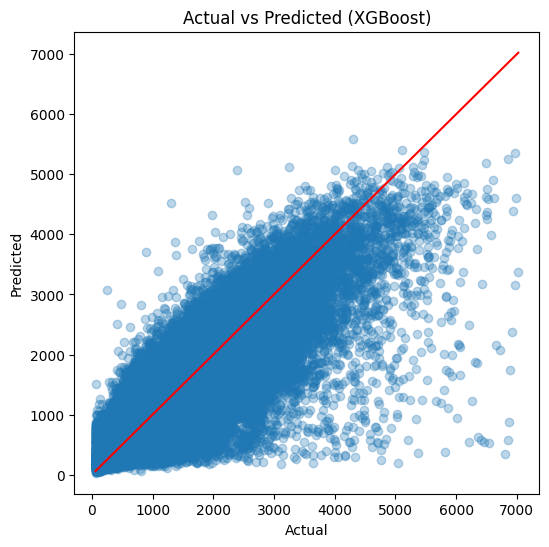

In [64]:
import matplotlib.pyplot as plt

# convert Spark → pandas
pred_df = xgb_prediction.select("label", "prediction").toPandas()

plt.figure(figsize=(6,6))
plt.scatter(pred_df["label"], pred_df["prediction"], alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (XGBoost)")

# perfect line
plt.plot(
    [pred_df["label"].min(), pred_df["label"].max()],
    [pred_df["label"].min(), pred_df["label"].max()],
    color='red'
)

plt.savefig("../reports/figures/actual_vs_predicted.png")
plt.show()

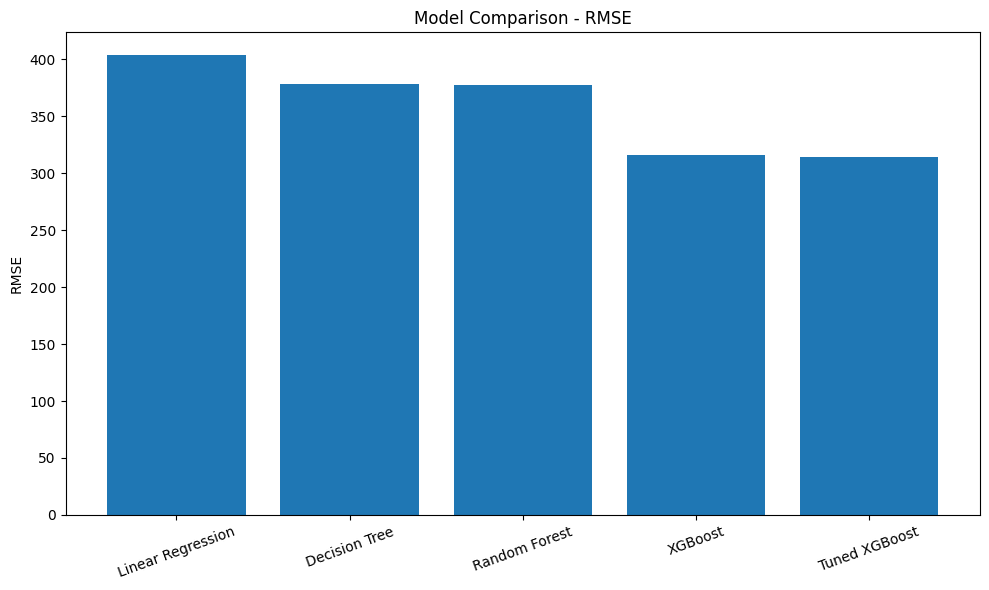

In [65]:
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

models = ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost", "Tuned XGBoost"]
rmse_scores = [403.4549, 378.4292, 377.3969, 315.5672, 313.7646]

plt.figure(figsize=(10, 6))
plt.bar(models, rmse_scores)
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_rmse.png")
plt.show()

2026-03-20 09:11:03,716 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


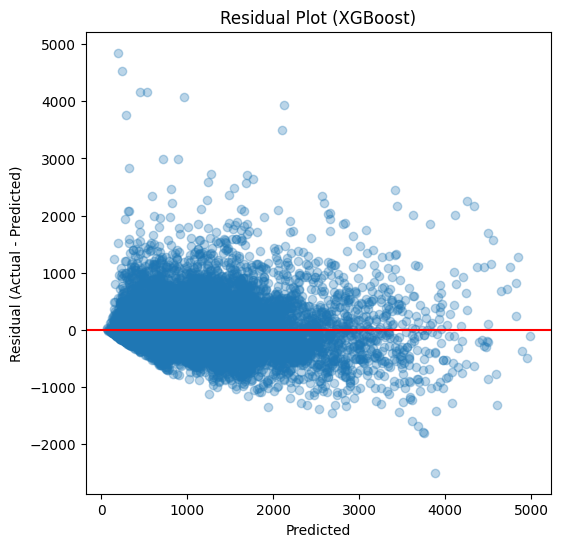

26/03/20 13:30:31 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 906789 ms exceeds timeout 120000 ms
26/03/20 13:30:31 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/20 13:30:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [66]:
residual_df = xgb_prediction.select("label", "prediction").sample(False, 0.1, seed=42).toPandas()
residual_df["residual"] = residual_df["label"] - residual_df["prediction"]

plt.figure(figsize=(6,6))
plt.scatter(residual_df["prediction"], residual_df["residual"], alpha=0.3)

plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (XGBoost)")

plt.savefig("../reports/figures/residual_plot.png")
plt.show()